# Baseline EDA — ZINC250K vs HMGCR reference

This notebook is the **CPU-only baseline** for the project: it asks how a
generic drug-like compound library (**ZINC250K**) compares to known HMG-CoA
reductase inhibitors (**ChEMBL CHEMBL402**) by Tanimoto similarity, with no
generative model in the loop.

It exists so the MolGPT v2 results in `EDA_MolGPT.ipynb` can be benchmarked
against a "what would random drugs look like" floor. For the GPU/MPS variant
of similarity scoring see `EDA_GPU.ipynb`.


In [1]:
# install Lib
#%pip install chembl_webresource_client

In [2]:
#Load Libraries
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit import DataStructs
from rdkit.DataStructs import BulkTanimotoSimilarity  # much faster for bulk comparisons
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import seaborn as sns
from multiprocessing import Pool, cpu_count   # for parallel processing we can try later

# Optional: live ChEMBL API. The data-loading cell below has a LOCAL_PATH
# fallback to datasets/statin_filtered.csv so the notebook still runs end-to-end
# in environments without this package or without internet access.
try:
    from chembl_webresource_client.new_client import new_client
    HAVE_CHEMBL_API = True
except ImportError:
    new_client = None
    HAVE_CHEMBL_API = False
    print("chembl_webresource_client not available -- will use LOCAL_PATH fallback for the reference set")


<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.


chembl_webresource_client not available -- will use LOCAL_PATH fallback for the reference set


In [3]:
# (Original cell: MPS sanity check. This notebook is CPU-only end-to-end --
# the torch/MPS check below is informational and is wrapped so a missing
# torch install doesn't break the rest of the notebook. For the GPU/MPS
# variant, see EDA_GPU.ipynb.)
try:
    import torch
    print(f"MPS available: {torch.backends.mps.is_available()}")
except ImportError:
    print("torch not installed (this notebook is CPU-only; MPS check skipped)")


torch not installed (this notebook is CPU-only; MPS check skipped)


## Data loading

In [4]:
# Step 1 — load ZINC250K candidates
url        = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
df         = pd.read_csv(url)
candidates = df["smiles"].tolist()[:100000]
print(f"Candidates: {len(candidates)}")

# Step 2 — load ChEMBL reference (HMG-CoA reductase, CHEMBL402)
# Falls back to the local filtered set if the ChEMBL API is unreachable.
LOCAL_PATH = "../datasets/statin_filtered.csv"
try:
    if not HAVE_CHEMBL_API:
        raise RuntimeError('chembl_webresource_client not installed')
    activity      = new_client.activity
    acts          = activity.filter(
                        target_chembl_id="CHEMBL402",
                        standard_type="IC50"
                    ).only("canonical_smiles")
    chembl_smiles = [a["canonical_smiles"] for a in acts if a["canonical_smiles"]]
    print(f"Reference (ChEMBL CHEMBL402): {len(chembl_smiles)}")
except Exception as e:
    print(f"ChEMBL API unavailable ({type(e).__name__}); "
          f"falling back to {LOCAL_PATH}")
    chembl_smiles = pd.read_csv(LOCAL_PATH)["smiles"].dropna().tolist()
    print(f"Reference (local fallback):  {len(chembl_smiles)}")

# Step 3 — fingerprint generator
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def encode(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return None
    return gen.GetFingerprint(mol)

# Step 4 — encode reference once
ref_fps = [fp for fp in [encode(s) for s in chembl_smiles] if fp is not None]
print(f"Valid reference fps: {len(ref_fps)}")

# Step 5 — encode all candidates in bulk first
print("Encoding candidates...")
candidate_fps = [(smi, encode(smi)) for smi in candidates]
candidate_fps = [(smi, fp) for smi, fp in candidate_fps if fp is not None]
print(f"Valid candidates: {len(candidate_fps)}")

# Step 6 — score in batches using numpy for max speed
print("Scoring...")
BATCH = 1000
results = []

for i in range(0, len(candidate_fps), BATCH):
    batch = candidate_fps[i:i+BATCH]
    for smi, fp in batch:
        scores = BulkTanimotoSimilarity(fp, ref_fps)
        results.append({"smiles": smi, "tanimoto": max(scores)})
    print(f"  processed {min(i+BATCH, len(candidate_fps))}/{len(candidate_fps)}")

df_results = pd.DataFrame(results)
hits       = df_results[df_results["tanimoto"] > 0.60].copy()
print(f"Scored: {len(df_results)}  Hits >0.60: {len(hits)}")


Candidates: 100000
ChEMBL API unavailable (RuntimeError); falling back to ../datasets/statin_filtered.csv
Reference (local fallback):  51
Valid reference fps: 51
Encoding candidates...


Valid candidates: 100000
Scoring...
  processed 1000/100000
  processed 2000/100000
  processed 3000/100000
  processed 4000/100000
  processed 5000/100000
  processed 6000/100000
  processed 7000/100000
  processed 8000/100000
  processed 9000/100000
  processed 10000/100000
  processed 11000/100000
  processed 12000/100000
  processed 13000/100000
  processed 14000/100000
  processed 15000/100000
  processed 16000/100000
  processed 17000/100000
  processed 18000/100000
  processed 19000/100000
  processed 20000/100000
  processed 21000/100000
  processed 22000/100000
  processed 23000/100000
  processed 24000/100000
  processed 25000/100000
  processed 26000/100000
  processed 27000/100000
  processed 28000/100000
  processed 29000/100000
  processed 30000/100000
  processed 31000/100000
  processed 32000/100000
  processed 33000/100000
  processed 34000/100000
  processed 35000/100000
  processed 36000/100000
  processed 37000/100000
  processed 38000/100000
  processed 39000/10000

  processed 52000/100000
  processed 53000/100000
  processed 54000/100000
  processed 55000/100000
  processed 56000/100000
  processed 57000/100000
  processed 58000/100000
  processed 59000/100000
  processed 60000/100000
  processed 61000/100000
  processed 62000/100000
  processed 63000/100000
  processed 64000/100000
  processed 65000/100000
  processed 66000/100000
  processed 67000/100000
  processed 68000/100000
  processed 69000/100000
  processed 70000/100000
  processed 71000/100000
  processed 72000/100000
  processed 73000/100000
  processed 74000/100000
  processed 75000/100000
  processed 76000/100000
  processed 77000/100000
  processed 78000/100000
  processed 79000/100000
  processed 80000/100000
  processed 81000/100000
  processed 82000/100000
  processed 83000/100000
  processed 84000/100000
  processed 85000/100000
  processed 86000/100000
  processed 87000/100000
  processed 88000/100000
  processed 89000/100000
  processed 90000/100000
  processed 91000/100000


## Fingerprint generation

In [5]:
# feature extraction for candidates
candidate_fps = []
for smi in candidates:
    fp = encode(smi)
    if fp is not None:
        candidate_fps.append(fp)
print(f"Valid candidate fingerprints: {len(candidate_fps)}")


Valid candidate fingerprints: 100000


## Similarity scoring

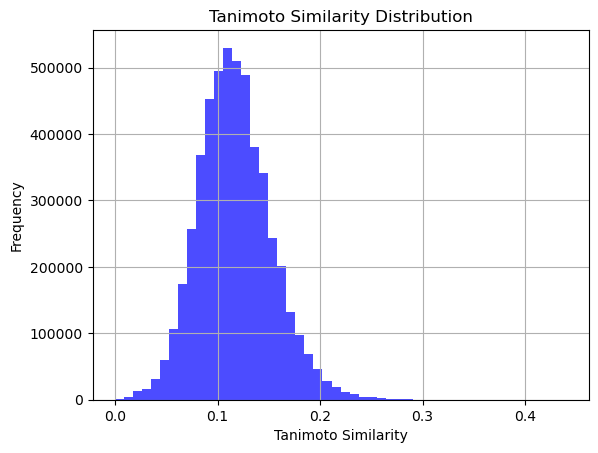

In [6]:
#plot similarity distribution
similarities = []
for c_fp in candidate_fps:
    for r_fp in ref_fps:
        sim = DataStructs.TanimotoSimilarity(c_fp, r_fp)
        similarities.append(sim)
plt.hist(similarities, bins=50, color='blue', alpha=0.7)
plt.title('Tanimoto Similarity Distribution')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Frequency')
plt.grid()
plt.show()


In [7]:
# STEP 5: Score all candidates 
results = []
for smi in candidates:
    fp = encode(smi)
    if fp is None: continue
    scores = [DataStructs.TanimotoSimilarity(fp, r) for r in ref_fps]
    results.append({"smiles": smi, "tanimoto": max(scores)})

df_results = pd.DataFrame(results)
print(f"\nAll candidates scored: {len(df_results)}")
print(df_results["tanimoto"].describe())

# STEP 6: Filter to statin-like hits (>0.40) 
hits = df_results[df_results["tanimoto"] > 0.40].copy()
print(f"\nCandidates passing Tanimoto >0.40: {len(hits)}")
# STEP 7: Filter to drug-like hits (Tanimoto > 0.6)
drug_like = df_results[df_results["tanimoto"] > 0.6].copy()
print(f"\nCandidates passing Tanimoto >0.6: {len(drug_like)}")  
drug_like = df_results[df_results["tanimoto"] > 0.7].copy()
print(f"\nCandidates passing Tanimoto >0.7: {len(drug_like)}")  


All candidates scored: 100000
count    100000.000000
mean          0.175588
std           0.038507
min           0.039474
25%           0.149425
50%           0.173913
75%           0.200000
max           0.440000
Name: tanimoto, dtype: float64

Candidates passing Tanimoto >0.40: 5

Candidates passing Tanimoto >0.6: 0

Candidates passing Tanimoto >0.7: 0


## Descriptor analysis

['smiles', 'tanimoto', 'mw', 'logp', 'hbd', 'hba', 'qed', 'violations']


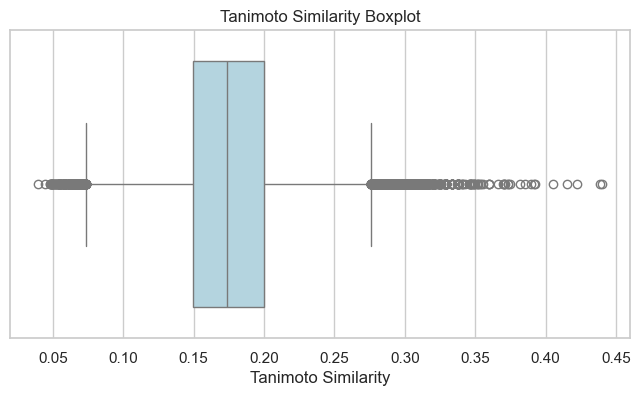

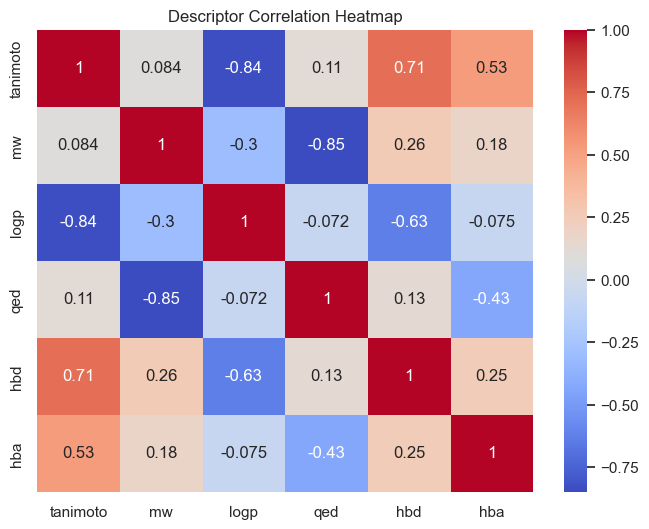

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# compute descriptors on hits
def get_descriptors(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return None
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {
        "mw": round(mw,2), "logp": round(logp,2),
        "hbd": hbd, "hba": hba,
        "qed": round(qed,3), "violations": viol
    }

hits["desc"] = hits["smiles"].apply(get_descriptors)
hits         = pd.concat([hits, hits["desc"].apply(pd.Series)], axis=1)
hits         = hits.drop(columns=["desc"])
print(hits.columns.tolist())

sns.set(style="whitegrid")

# Plot 1 — Tanimoto boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_results["tanimoto"], color="lightblue")
plt.title("Tanimoto Similarity Boxplot")
plt.xlabel("Tanimoto Similarity")
plt.show()

# Plot 2 — Descriptor correlation heatmap (hits only)
plt.figure(figsize=(8, 6))
sns.heatmap(
    hits[["tanimoto","mw","logp","qed","hbd","hba"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Descriptor Correlation Heatmap")
plt.show()

<Axes: xlabel='group', ylabel='tanimoto'>

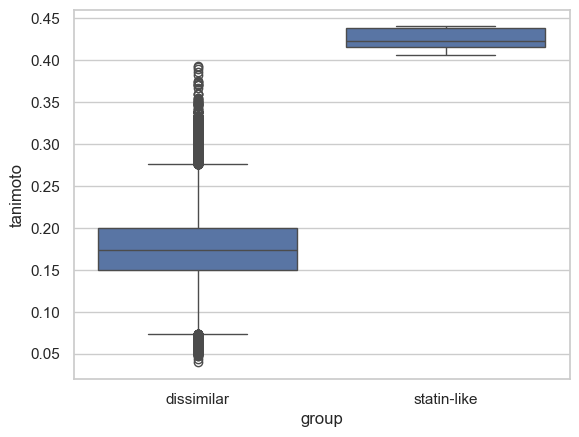

In [9]:
#hits vs all candidates
df_results["group"] = df_results["tanimoto"].apply(
    lambda x: "statin-like" if x > 0.40 else "dissimilar"
)
sns.boxplot(data=df_results, x="group", y="tanimoto")

In [10]:
# STEP 7: Drug-likeness descriptors on hits
def get_descriptors(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return None
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {
        "mw":         round(mw,   2),
        "logp":       round(logp, 2),
        "hbd":        hbd,
        "hba":        hba,
        "qed":        round(qed,  3),
        "violations": viol
    }

#STEP 8: PAINS filter on hits 
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains  = FilterCatalog(params)

def has_pains(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return True
    return pains.GetFirstMatch(mol) is not None

if "mw" not in hits.columns:   # idempotency guard (the earlier descriptor cell may have already added these)
    hits["desc"]       = hits["smiles"].apply(get_descriptors)
    hits               = pd.concat([hits, hits["desc"].apply(pd.Series)], axis=1)
    hits               = hits.drop(columns=["desc"])
hits["pains_flag"] = hits["smiles"].apply(has_pains)

# STEP 9: Summary
print("\nDescriptor summary of hits:")
print(hits[["tanimoto","mw","logp","qed","violations"]].describe())

passed_lipinski = (hits["violations"] == 0).sum()
pains_flagged   = hits["pains_flag"].sum()
clean           = ((hits["violations"] == 0) & (~hits["pains_flag"])).sum()

print(f"\nPassed Lipinski (0 violations): {passed_lipinski}")
print(f"PAINS flagged:                  {pains_flagged}")
print(f"Clean candidates:               {clean}")

print("\nAll hits:")
print(hits[["smiles","tanimoto","mw","logp","qed","violations","pains_flag"]])



Descriptor summary of hits:
       tanimoto         mw      logp       qed  violations
count  5.000000    5.00000  5.000000  5.000000         5.0
mean   0.424376  363.42800  3.466000  0.710000         0.0
std    0.014833   21.77833  0.340925  0.043835         0.0
min    0.405405  334.42000  2.930000  0.668000         0.0
25%    0.415584  353.40000  3.420000  0.676000         0.0
50%    0.422535  365.41000  3.500000  0.700000         0.0
75%    0.438356  370.45000  3.630000  0.731000         0.0
max    0.440000  393.46000  3.850000  0.775000         0.0

Passed Lipinski (0 violations): 5
PAINS flagged:                  0
Clean candidates:               5

All hits:
                                                  smiles  tanimoto      mw  \
13868  COc1cn(-c2ccccc2)nc1C(=O)N(C)[C@@H](C)c1ccc(F)...  0.405405  353.40   
20480   CCc1cc(=O)n(CC(=O)NCc2ccc(F)cc2)c(-c2ccccc2)n1\n  0.440000  365.41   
38282  Cc1cc(=O)n(CC(=O)N[C@@H](C)CCc2ccccc2)c(-c2ccc...  0.415584  393.46   
60670   C[C@H]

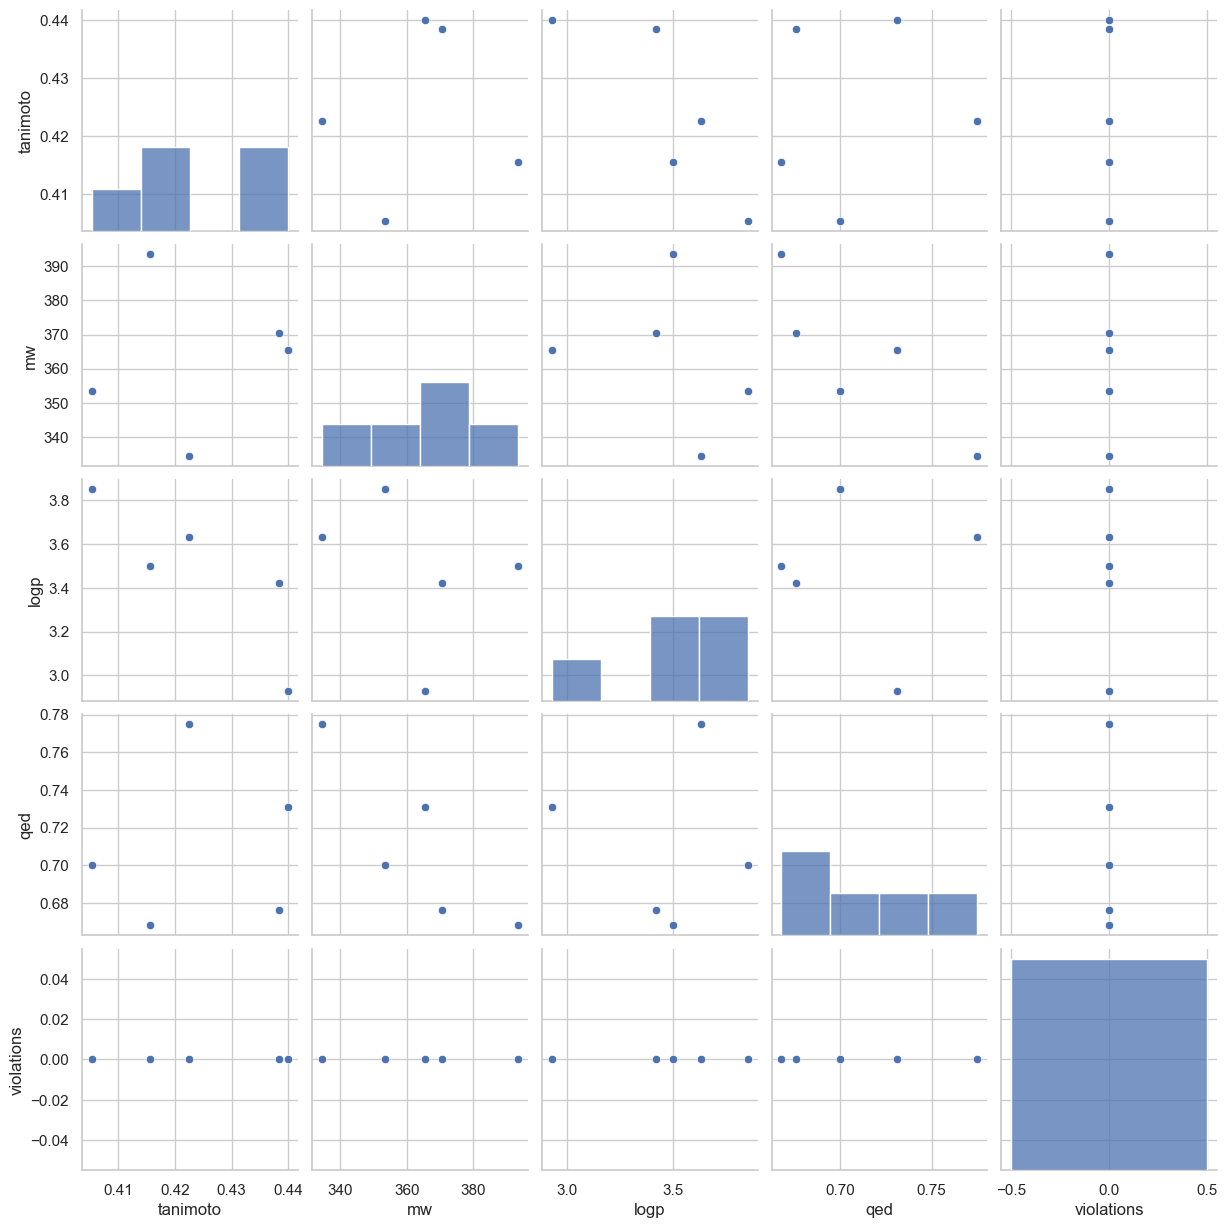

In [11]:
#pairplot
sns.pairplot(
    hits[["tanimoto","mw","logp","qed","violations"]],
    diag_kind="hist"
)

## Filter funnel

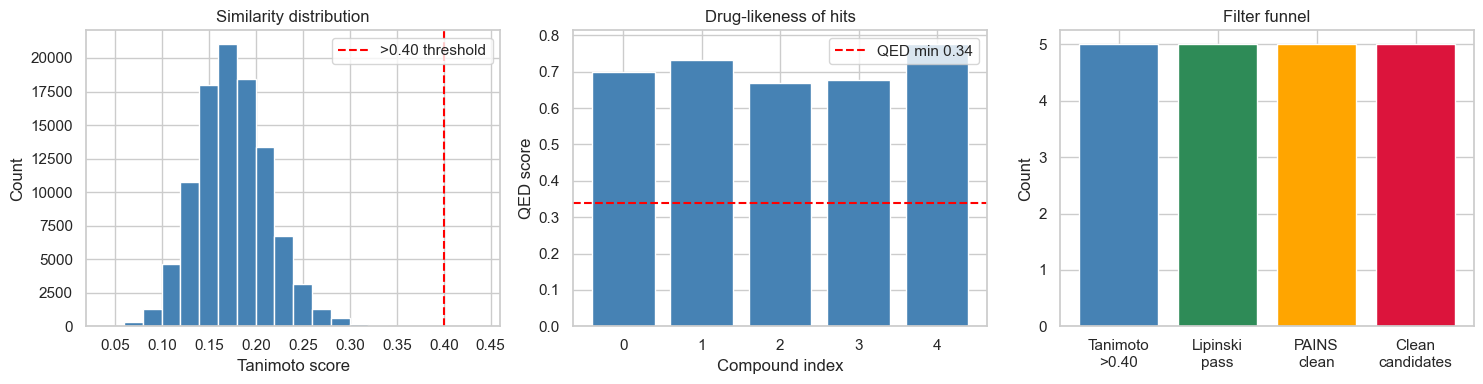

In [12]:
# STEP 10: Visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Tanimoto distribution
axes[0].hist(df_results["tanimoto"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(0.40, color="red",    linestyle="--", label=">0.40 threshold")
axes[0].set_xlabel("Tanimoto score")
axes[0].set_ylabel("Count")
axes[0].set_title("Similarity distribution")
axes[0].legend()

# Plot 2 — QED distribution of hits
if len(hits) > 0:
    axes[1].bar(range(len(hits)), hits["qed"], color="steelblue", edgecolor="white")
    axes[1].axhline(0.34, color="red", linestyle="--", label="QED min 0.34")
    axes[1].set_xlabel("Compound index")
    axes[1].set_ylabel("QED score")
    axes[1].set_title("Drug-likeness of hits")
    axes[1].legend()

# Plot 3 — Filter summary
labels  = ["Tanimoto\n>0.40", "Lipinski\npass", "PAINS\nclean", "Clean\ncandidates"]
values  = [len(hits), passed_lipinski, len(hits)-pains_flagged, clean]
colors  = ["steelblue", "seagreen", "orange", "crimson"]
axes[2].bar(labels, values, color=colors, edgecolor="white")
axes[2].set_ylabel("Count")
axes[2].set_title("Filter funnel")

plt.tight_layout()
plt.show()


## Marketed statin comparison

In [13]:
# Score ChEMBL compounds against the 7 marketed statins.
# Canonical SMILES verified against PubChem PUG REST -- see
# EDA/marketed_statins.py (single source of truth across the project).
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))   # EDA/ when notebook runs from there
from marketed_statins import MARKETED_STATINS

known_statins = list(MARKETED_STATINS.items())
statin_fps = [(name, encode(smi)) for name, smi in known_statins]
statin_fps = [(name, fp) for name, fp in statin_fps if fp is not None]
print(f"Marketed-statin reference fingerprints: {len(statin_fps)}")

scores = []
for smi in chembl_smiles:
    fp = encode(smi)
    if fp is None: continue
    best = max(BulkTanimotoSimilarity(fp, [sfp for _, sfp in statin_fps]))
    scores.append(best)

import pandas as pd
s = pd.Series(scores)
print(s.describe())
print(f"Statin-like >0.70: {(s > 0.70).sum()}")
print(f"Statin-like >0.60: {(s > 0.60).sum()}")
print(f"Statin-like >0.40: {(s > 0.40).sum()}")


Marketed-statin reference fingerprints: 7
count    51.000000
mean      0.528871
std       0.178733
min       0.223404
25%       0.441400
50%       0.463415
75%       0.564606
max       1.000000
dtype: float64
Statin-like >0.70: 8
Statin-like >0.60: 11
Statin-like >0.40: 44
